In [16]:
# Import packages and set plot parameters
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks
from math import log10, floor
plt.rcParams['figure.dpi'] = 150

In [17]:
# Define second gradient function
def second_gradient(i):
    di = np.gradient(i)
    y = gaussian_filter1d(-np.gradient(di),sigma=2)
    return y

# Define function to get x and y position of peaks
def peaks(r,y,h):
    p = find_peaks(y,height=h,distance=20)
    ph = p[1]['peak_heights']
    pp = r[p[0]]
    return pp,ph

# Define function for rounding to significant figures
def round_to_sig_figs(x,sig=4):
    if x == 0:
        return 0
    return round(x,sig - int(floor(log10(abs(x)))) - 1)

In [18]:
# Import data and define variables
b3 = np.genfromtxt('Data/B0959.3c_MapAvr_26-03-04.txt',delimiter='\t')
b3r = b3[:-75,0]
b3i = b3[:-75,1]
b3y = second_gradient(b3i)
p3p,p3h = peaks(b3r,b3y,2)

b4 = np.genfromtxt('Data/B0959.4c_MapAvr_26-03-04.txt',delimiter='\t')
b4r = b4[:-75,0]
b4i = b4[:-75,1]
b4y = second_gradient(b4i)
p4p,p4h = peaks(b4r,b4y,2)

b5 = np.genfromtxt('Data/B0959.5a_MapAvr_26-03-06.txt',delimiter='\t')
b5r = b5[:-75,0]
b5i = b5[:-75,1]
b5y = second_gradient(b5i)
p5p,p5h = peaks(b5r,b5y,4)

b8 = np.genfromtxt('Data/B0959.8c_MapAvr_26-03-06.txt',delimiter='\t')
b8r = b8[:-75,0]
b8i = b8[:-75,1]
b8y = second_gradient(b8i)
p8p,p8h = peaks(b8r,b8y,3)

b15 = np.genfromtxt('Data/B0959.15a_MapAvr_26-03-18.txt',delimiter='\t')
b15r = b15[:-75,0]
b15i = b15[:-75,1]
b15y = second_gradient(b15i)
p15p,p15h = peaks(b15r,b15y,7)

b16 = np.genfromtxt('Data/B0959.16b_MapAvr_26-03-18.txt',delimiter='\t')
b16r = b16[:-75,0]
b16i = b16[:-75,1]
b16y = second_gradient(b16i)
p16p,p16h = peaks(b16r,b16y,1.3)

h = np.genfromtxt('Data/RRUFF_Hematite_R060190_Eng.txt',delimiter=', ')
hr = h[:-75,0]
hi = h[:-75,1]
hy = second_gradient(hi)
php,phh = peaks(hr,hy,7)

Text(0.5, 0, 'Raman Shift (cm-1)')

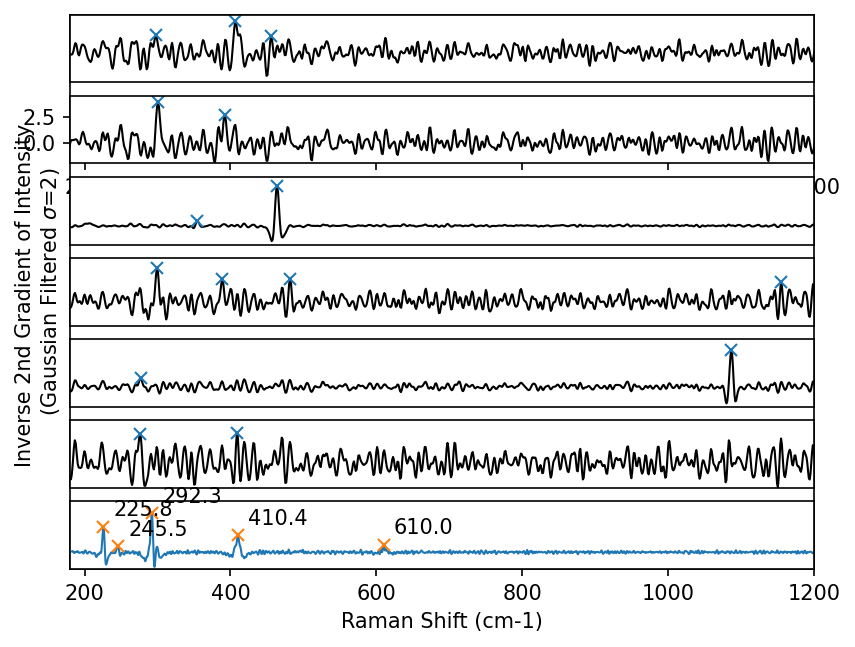

In [20]:
frame1 = plt.gca()
plt.subplot(711)
plt.plot(b3r,b3y,c='Black',linewidth=1)
plt.plot(p3p,p3h,"x")
plt.xlim(180,1200)
plt.ylim(-4,5)
frame1.axes.get_yaxis().set_ticks([])
frame1.axes.get_xaxis().set_ticks([])

frame2 = plt.gca()
plt.subplot(712)
plt.plot(b4r,b4y,c='Black',linewidth=1)
plt.plot(p4p,p4h,"x")
plt.xlim(180,1200)
plt.ylim(-2,4.5)
frame2.axes.get_yaxis().set_ticks([])
frame2.axes.get_xaxis().set_ticks([])

plt.subplot(713)
frame3 = plt.gca()
plt.plot(b5r,b5y,c='Black',linewidth=1)
plt.plot(p5p,p5h,"x")
plt.xlim(180,1200)
plt.ylim(-17,44)
frame3.axes.get_yaxis().set_ticks([])
frame3.axes.get_xaxis().set_ticks([])

plt.subplot(714)
frame4 = plt.gca()
plt.plot(b8r,b8y,c='Black',linewidth=1)
plt.plot(p8p,p8h,"x")
plt.xlim(180,1200)
plt.ylim(-4,7)
frame4.axes.get_yaxis().set_ticks([])
frame4.axes.get_xaxis().set_ticks([])
plt.ylabel('Inverse 2nd Gradient of Intensity \n(Gaussian Filtered $\\sigma$=2)')

plt.subplot(715)
frame5 = plt.gca()
plt.plot(b15r,b15y,c='Black',linewidth=1)
plt.plot(p15p,p15h,"x")
plt.xlim(180,1200)
plt.ylim(-17,40)
frame5.axes.get_yaxis().set_ticks([])
frame5.axes.get_xaxis().set_ticks([])

plt.subplot(716)
frame6 = plt.gca()
plt.plot(b16r,b16y,c='Black',linewidth=1)
plt.plot(p16p,p16h,"x")
plt.xlim(180,1200)
plt.ylim(-1.2,2)
frame6.axes.get_yaxis().set_ticks([])
frame6.axes.get_xaxis().set_ticks([])

plt.subplot(717)
frame7 = plt.gca()
plt.plot(hr,hy,linewidth=1) 
plt.plot(php,phh,"x")
for i,j in zip(php,phh):
    plt.annotate(round_to_sig_figs(i),xy=(i,j),xytext=(5, 5),textcoords='offset points')
plt.xlim(180,1200)
plt.ylim(-20,60)
frame7.axes.get_yaxis().set_ticks([])
plt.xlabel('Raman Shift (cm-1)')